# Le Monde URL archive counts

This notebook builds two dataframes from `/Users/msfr/le_monde_archive/url`:

1. number of files in each year subfolder
2. line counts for every URL file, with a parsed datetime column

It also plots both results.

In [1]:
import importlib.util
import subprocess
import sys

required = ["pandas", "numpy", "matplotlib"]
missing = [pkg for pkg in required if importlib.util.find_spec(pkg) is None]
if missing:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)
    print(f"Installed: {', '.join(missing)}")
else:
    print("All packages already available")

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


Installed: pandas, numpy, matplotlib



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python3.11 -m pip install --upgrade pip


In [28]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

archive_root = Path("/Users/msfr/le_monde_archive/url")

def count_lines(path: Path) -> int:
    with path.open(encoding="utf-8") as handle:
        return sum(1 for _ in handle)

year_dirs = sorted(
    [path for path in archive_root.iterdir() if path.is_dir() and path.name.isdigit()],
    key=lambda path: int(path.name),
)

year_rows = []
for year_dir in year_dirs:
    file_count = sum(1 for path in year_dir.glob("*.txt") if path.is_file())
    year_rows.append({"year": int(year_dir.name), "n_files": file_count})

year_files_df = pd.DataFrame(year_rows).sort_values("year").reset_index(drop=True)

url_rows = []
for year_dir in year_dirs:
    for path in sorted(year_dir.glob("*.txt")):
        if not path.is_file():
            continue
        datetime_value = pd.to_datetime(path.stem, format="%Y%m%d", errors="coerce")
        url_rows.append(
            {
                "year": int(year_dir.name),
                "datetime": datetime_value,
                "n_urls": count_lines(path),
                "file": path.name,
            }
        )

urls_df = pd.DataFrame(url_rows)
urls_df = urls_df.dropna(subset=["datetime"]).sort_values("datetime").reset_index(drop=True)

print(f"Year folders found: {len(year_files_df)}")
print(f"URL files found: {len(urls_df)}")

year_files_df.head(), urls_df.head()

Year folders found: 83
URL files found: 29747


(   year  n_files
 0  1944       13
 1  1945      365
 2  1946      365
 3  1947      365
 4  1948      365,
    year   datetime  n_urls          file
 0  1944 1944-12-19      36  19441219.txt
 1  1944 1944-12-20      53  19441220.txt
 2  1944 1944-12-21      55  19441221.txt
 3  1944 1944-12-22      41  19441222.txt
 4  1944 1944-12-23      41  19441223.txt)

In [29]:
year_files_df.loc[year_files_df["n_files"] < 365]

,year,n_files
0,1944,13
82,2026,151


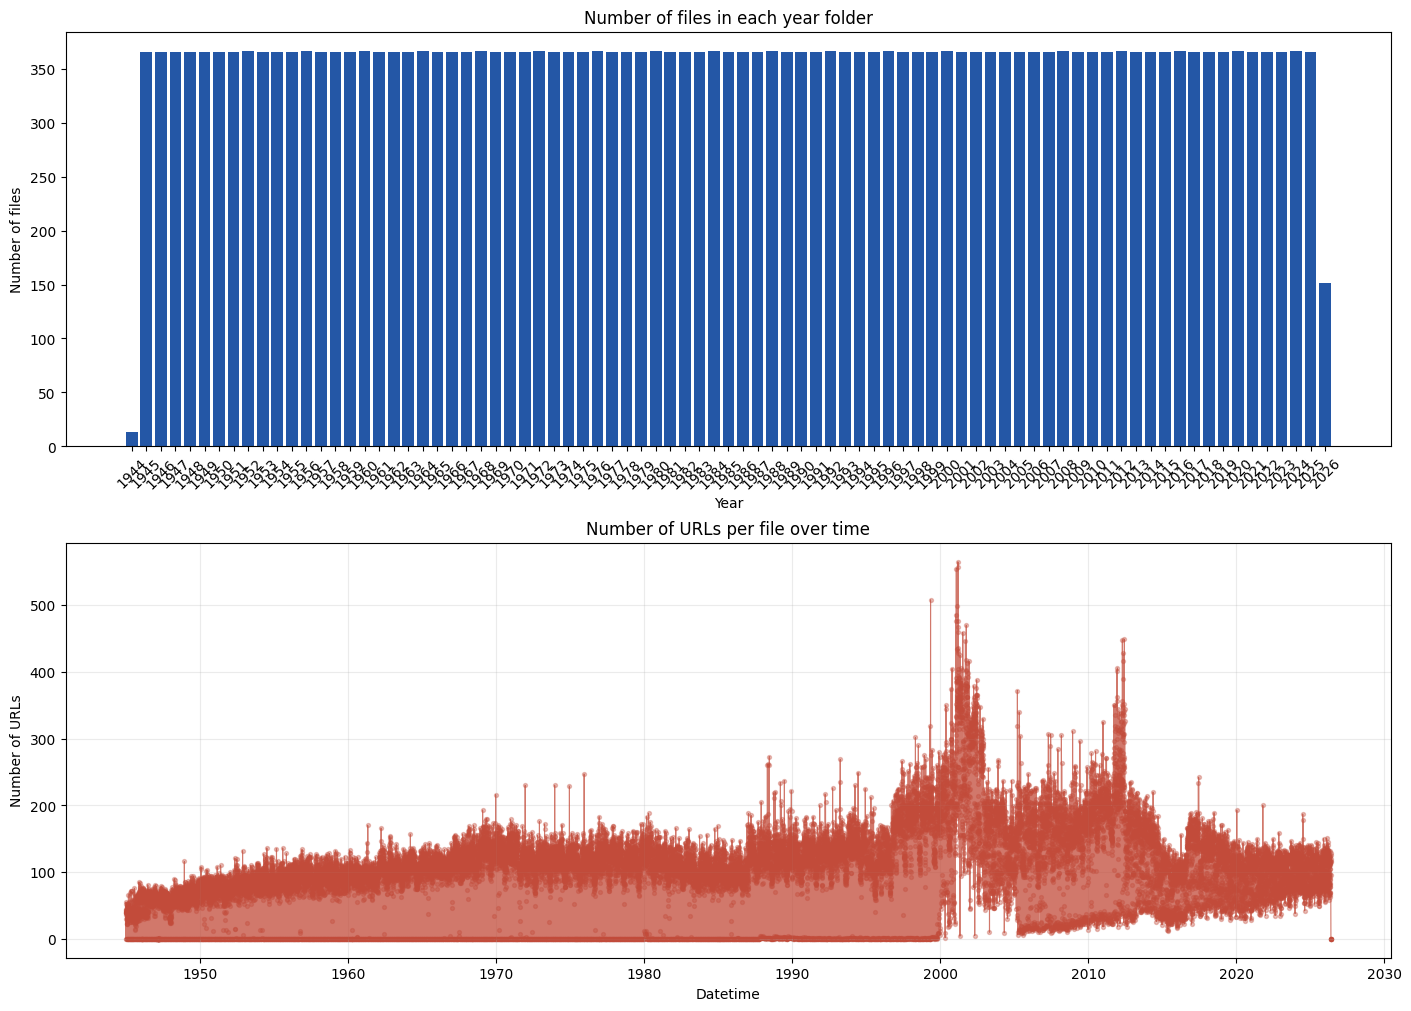

In [30]:

fig, axes = plt.subplots(2, 1, figsize=(14, 10), constrained_layout=True)

axes[0].bar(year_files_df["year"].astype(str), year_files_df["n_files"], color="#2457A6")
axes[0].set_title("Number of files in each year folder")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Number of files")
axes[0].tick_params(axis="x", rotation=45)

axes[1].plot(urls_df["datetime"], urls_df["n_urls"], color="#C24B3A", linewidth=0.8, alpha=0.75)
axes[1].scatter(urls_df["datetime"], urls_df["n_urls"], color="#C24B3A", s=8, alpha=0.35)
axes[1].set_title("Number of URLs per file over time")
axes[1].set_xlabel("Datetime")
axes[1].set_ylabel("Number of URLs")
axes[1].grid(True, alpha=0.25)

plt.show()

In [33]:
# Add weekday names (Monday, Tuesday, etc.) from the datetime column
urls_df["weekday"] = urls_df["datetime"].dt.day_name()

# Optional: numeric weekday (Monday=0 ... Sunday=6)
urls_df["weekday_num"] = urls_df["datetime"].dt.weekday

urls_df[["datetime", "weekday", "weekday_num", "n_urls"]].head()

,datetime,weekday,weekday_num,n_urls
0,1944-12-19,Tuesday,1,36
1,1944-12-20,Wednesday,2,53
2,1944-12-21,Thursday,3,55
3,1944-12-22,Friday,4,41
4,1944-12-23,Saturday,5,41


In [43]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

# Example: full display without truncation
urls_df.loc[urls_df.n_urls==0].tail(800)

,year,datetime,n_urls,file,weekday,weekday_num
12737,1979,1979-11-04,0,19791104.txt,Sunday,6
12744,1979,1979-11-11,0,19791111.txt,Sunday,6
12751,1979,1979-11-18,0,19791118.txt,Sunday,6
12758,1979,1979-11-25,0,19791125.txt,Sunday,6
12765,1979,1979-12-02,0,19791202.txt,Sunday,6
12772,1979,1979-12-09,0,19791209.txt,Sunday,6
12779,1979,1979-12-16,0,19791216.txt,Sunday,6
12786,1979,1979-12-23,0,19791223.txt,Sunday,6
12793,1979,1979-12-30,0,19791230.txt,Sunday,6
12856,1980,1980-03-02,0,19800302.txt,Sunday,6


In [37]:
urls_df.loc[urls_df["n_urls"] == 0, ["year", "datetime", "weekday", "file", "n_urls"]].tail(100)

,year,datetime,weekday,file,n_urls
19010,1997,1997-01-06,Monday,19970106.txt,0
19017,1997,1997-01-13,Monday,19970113.txt,0
19031,1997,1997-01-27,Monday,19970127.txt,0
19038,1997,1997-02-03,Monday,19970203.txt,0
19045,1997,1997-02-10,Monday,19970210.txt,0
...,...,...,...,...,...
29742,2026,2026-05-27,Wednesday,20260527.txt,0
29743,2026,2026-05-28,Thursday,20260528.txt,0
29744,2026,2026-05-29,Friday,20260529.txt,0
29745,2026,2026-05-30,Saturday,20260530.txt,0


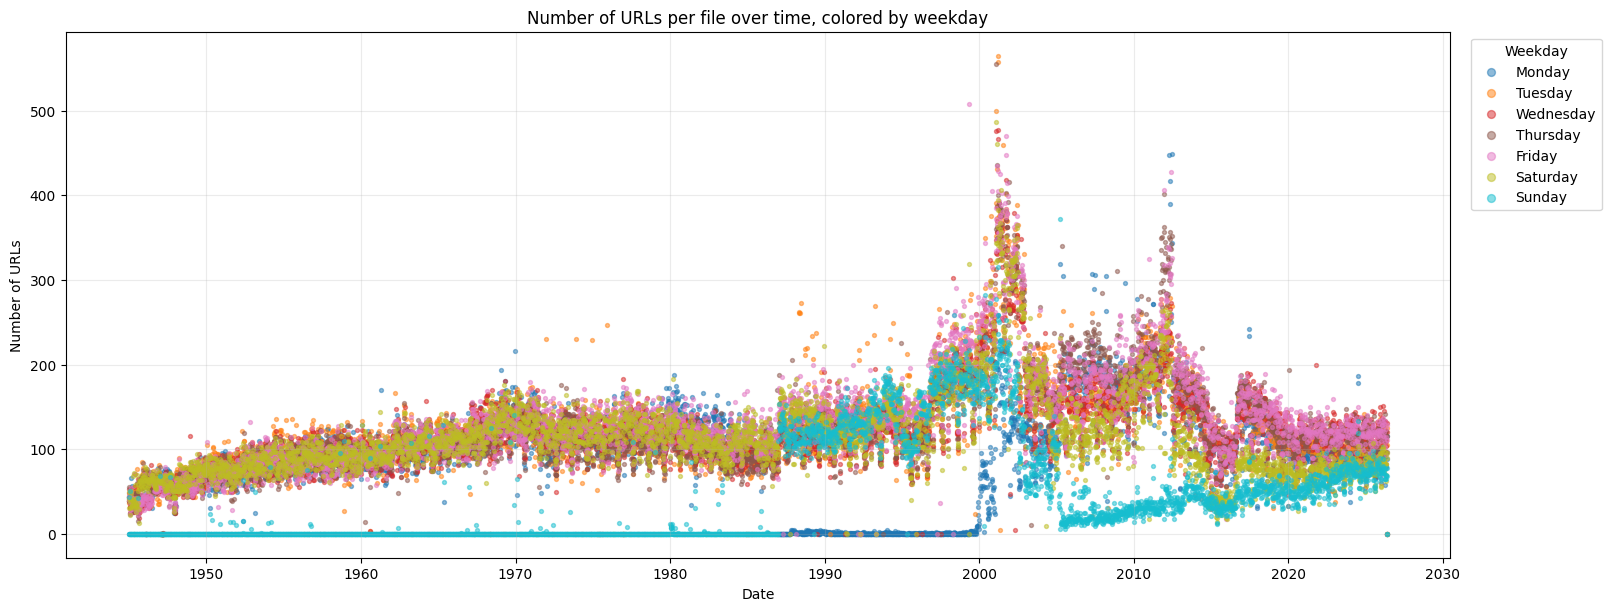

In [40]:
import numpy as np

# Plot n_urls over time, colored by weekday
import matplotlib.pyplot as plt
import matplotlib.cm as cm

weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
colors = cm.tab10(np.linspace(0, 1, 7))
weekday_color = {day: colors[i] for i, day in enumerate(weekday_order)}

fig, ax = plt.subplots(figsize=(16, 6), constrained_layout=True)

for weekday in weekday_order:
    mask = urls_df["weekday"] == weekday
    subset = urls_df.loc[mask]
    ax.scatter(subset["datetime"], subset["n_urls"], label=weekday, color=weekday_color[weekday], s=8, alpha=0.5)

ax.set_title("Number of URLs per file over time, colored by weekday")
ax.set_xlabel("Date")
ax.set_ylabel("Number of URLs")
ax.legend(title="Weekday", markerscale=2, bbox_to_anchor=(1.01, 1), loc="upper left")
ax.grid(True, alpha=0.25)
plt.show()

In [36]:
urls_df.loc[urls_df["n_urls"] == 0, ["year", "datetime", "file", "n_urls"]]

,year,datetime,file,n_urls
5,1944,1944-12-24,19441224.txt,0
12,1944,1944-12-31,19441231.txt,0
20,1945,1945-01-08,19450108.txt,0
27,1945,1945-01-15,19450115.txt,0
33,1945,1945-01-21,19450121.txt,0
...,...,...,...,...
29742,2026,2026-05-27,20260527.txt,0
29743,2026,2026-05-28,20260528.txt,0
29744,2026,2026-05-29,20260529.txt,0
29745,2026,2026-05-30,20260530.txt,0


In [ ]:
year_files_df, urls_df.head(10)